In [1]:
import funky.snanawrap as f
import funky.nreblocks as nb
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import corner
import pandas as pd
import emcee
import pickle
rng=np.random.default_rng(seed=1)

# Original

In [6]:
with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)
N = 5500  # select number of TRAINING sims
N_val = 700
N_lc = 73  # lc per sim (maximum possible over all sims)
#get minimum lenght to have maxitems per omega/lambda couple.
# lc_per_sim = []
# for i in range(N):
#     nlc = sims[i].get('zhd').shape[0]  # should be 73
#     lc_per_sim.append(nlc)
# N_lc = np.min(lc_per_sim)
# print('miminum simulation per omega,w:', N_lc)

# training
theta = np.empty((N, 2))
mu = np.empty((N, N_lc))
zhd = np.empty((N, N_lc))
for i in range(N):
    theta[i] = (sims[i].get('omega'), sims[i].get('w'))
    mu[i] = sims[i].get('mu')[:N_lc]
    zhd[i] = sims[i].get('zhd')[:N_lc]

# validation
theta_val = np.empty((N_val, 2))
mu_val = np.empty((N_val, N_lc))
zhd_val = np.empty((N_val, N_lc))
for i, j in enumerate(range(N, N + N_val)):
    theta_val[i] = (sims[j].get('omega'), sims[j].get('w'))
    mu_val[i] = sims[j].get('mu')[:N_lc]
    zhd_val[i] = sims[j].get('zhd')[:N_lc]

/tmp/ipykernel_9474/1551209932.py:1: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)


In [ ]:
# standardise
theta_mean, theta_std = theta.mean(axis=0), theta.std(axis=0)
mu_mean, mu_std = mu.mean(axis=0), mu.std(axis=0)
zhd_mean, zhd_std = zhd.mean(axis=0), zhd.std(axis=0)

mu = torch.tensor((mu - mu_mean) / mu_std).float()
zhd = torch.tensor((zhd - zhd_mean) / zhd_std).float()
theta = torch.tensor((theta - theta_mean) / theta_std).float()
x = torch.cat([mu,zhd], dim=1)

mu_val = torch.tensor((mu_val - mu_mean) / mu_std).float()
zhd_val = torch.tensor((zhd_val - zhd_mean) / zhd_std).float()
theta_val = torch.tensor((theta_val - theta_mean) / theta_std).float()
x_val = torch.cat([mu_val,zhd_val], dim=1)
# save means and stds, we need them to standardise the test
np.savez("/home/ubuntu/SNANA/nre/gioTesting/meansNstds.npz", theta_mean=theta_mean, theta_std=theta_std, mu_mean=mu_mean, mu_std=mu_std, zhd_mean=zhd_mean, zhd_std=zhd_std)

# train nre
nre = nb.NeuralRatioEstimator(x_dim=N_lc*2, theta_dim=2, hidden_dim=512, layers=10)

batch_size = 100

dataset_train, dataset_val = TensorDataset(x, theta), TensorDataset(x_val, theta_val)

train_loader = DataLoader(dataset_train, batch_size=batch_size, num_workers=3, pin_memory=True, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, num_workers=3, pin_memory=True, shuffle=False)
logger = pl.loggers.CSVLogger('nreTestLogs', name="original")
trainer = pl.Trainer(max_epochs=50, logger=logger)
nre.train()
trainer.fit(model=nre, train_dataloaders=train_loader, val_dataloaders=val_loader)

In [ ]:
# nre scores
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")

# Aggregate by epoch to remove NaNs
# This takes the non-NaN value for each epoch
epoch_metrics = metrics.groupby('epoch').max()

plt.figure(figsize=(10, 5))


# Plot from the aggregated dataframe
if 'train_loss' in epoch_metrics.columns:
    plt.plot(epoch_metrics.index, epoch_metrics['train_loss'], label='Train Loss')

if 'val_loss' in epoch_metrics.columns:
    plt.plot(epoch_metrics.index, epoch_metrics['val_loss'], label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('NRE Training Progress (Aggregated)')
plt.show()

In [ ]:
npLoad = np.load("/home/ubuntu/SNANA/nre/gioTesting/meansNstds.npz")
theta_mean = npLoad["theta_mean"]
theta_std = npLoad["theta_std"]
mu_mean = npLoad["mu_mean"]
mu_std = npLoad["mu_std"]
zhd_mean = npLoad["zhd_mean"]
zhd_std = npLoad["zhd_std"]

npLoad.close()

nre = nb.NeuralRatioEstimator.load_from_checkpoint('nreTestLogs/original/version_1/checkpoints/epoch=49-step=2750.ckpt', x_dim=73*2, theta_dim=2, hidden_dim=512, layers=10)
nre.eval()

In [3]:
muReal, zReal = f.extract_mu_zhd_from_file('/home/ubuntu/SNANA/salt2mus/realdata/SALT2mu_realdata.FITRES')

ndim, nwalkers = 2, 32
sampler = emcee.EnsembleSampler(nwalkers, ndim, nb.log_post, args=(muReal, zReal, theta_mean, theta_std, mu_mean, mu_std, zhd_mean, zhd_std, nre, False))  # Init

# pos = rng.standard_normal((nwalkers, ndim))  # should be np.random.randn equivalent # starting theta position
pos = rng.uniform((0, -3), (1, 0), size=(nwalkers, ndim))
sampler.run_mcmc(pos, 5000, progress=True)  # run

100%|██████████████████████████████████████████████████████████████| 5000/5000 [05:53<00:00, 14.14it/s]


State([[ 0.55597337 -0.5913366 ]
 [ 0.46032702 -0.4795807 ]
 [ 0.21126123 -1.02203368]
 [ 0.49470847 -0.99224786]
 [ 0.56226689 -2.87178028]
 [ 0.73107781 -0.78901613]
 [ 0.39940521 -1.5828256 ]
 [ 0.6366513  -0.54576983]
 [ 0.02247612 -0.61135947]
 [ 0.50518648 -1.78780894]
 [ 0.69741666 -2.6779216 ]
 [ 0.44340695 -1.73285631]
 [ 0.77093438 -1.21508475]
 [ 0.37113897 -1.72168326]
 [ 0.35608837 -1.99585217]
 [ 0.57268693 -1.67241944]
 [ 0.37246843 -1.5168432 ]
 [ 0.33299295 -2.46884587]
 [ 0.398416   -1.99996067]
 [ 0.83428132 -2.59248715]
 [ 0.69203095 -0.91978328]
 [ 0.84989324 -0.93099967]
 [ 0.8910946  -0.3451975 ]
 [ 0.03811136 -2.23198734]
 [ 0.17015709 -1.06069648]
 [ 0.94698298 -1.66275436]
 [ 0.36062921 -0.77887191]
 [ 0.27565601 -1.96694109]
 [ 0.74540941 -0.56664506]
 [ 0.63617789 -1.5594644 ]
 [ 0.44081679 -1.32981145]
 [ 0.21103517 -0.56864766]], log_prob=[-1.72713968e+11 -1.73865140e+11 -2.55834685e+11 -2.76622836e+11
 -1.27127749e+11 -1.77925407e+11 -2.88530661e+11 -1.82

In [4]:
sampler.get_autocorr_time(discard=1000)

/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 80;
tau: [558.4877248         nan]

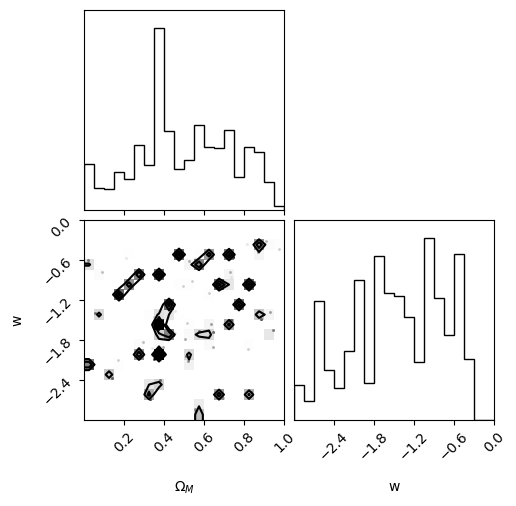

In [5]:
flat_samples = sampler.get_chain(discard=0, thin=200, flat=True)  # get chain, look for what's flat
corner.corner(flat_samples, range=[(0, 1), (-3,0)], labels=[r"$\Omega_M$", "w"])
plt.show()

# Summary Stats in NRE, I don't know what I'm doing anymore, help pls
Same as above, but we use `f.smoother` to smooth the lcs

In [2]:
with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)
N = 5500  # select number of TRAINING sims
N_val = 700
N_lc = 100  # lc per sim (maximum possible over all sims)  ### smoothing gives 100 points

theta = np.empty((N, 2))
mu = np.empty((N, N_lc))
zhd = np.empty((N, N_lc))
for i in range(N):
    theta[i] = (sims[i].get('omega'), sims[i].get('w'))
    zhd[i], mu[i] = f.smoother(sims[i].get('zhd'), sims[i].get('mu'))

# validation
theta_val = np.empty((N_val, 2))
mu_val = np.empty((N_val, N_lc))
zhd_val = np.empty((N_val, N_lc))
for i, j in enumerate(range(N, N + N_val)):
    theta_val[i] = (sims[j].get('omega'), sims[j].get('w'))
    zhd_val[i], mu_val[i] = f.smoother(sims[j].get('zhd'), sims[j].get('mu'))

/tmp/ipykernel_20344/563579958.py:1: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)


In [ ]:
# standardise
theta_mean, theta_std = theta.mean(axis=0), theta.std(axis=0)
mu_mean, mu_std = mu.mean(axis=0), mu.std(axis=0)

mu = torch.tensor((mu - mu_mean) / mu_std).float()
theta = torch.tensor((theta - theta_mean) / theta_std).float()
x = mu

mu_val = torch.tensor((mu_val - mu_mean) / mu_std).float()
theta_val = torch.tensor((theta_val - theta_mean) / theta_std).float()
x_val = mu_val  # I don't want z anymore
# save means and stds, we need them to standardise the test
np.savez("/home/ubuntu/SNANA/nre/gioTesting/meansNstdsSummarisedNoZ.npz", theta_mean=theta_mean, theta_std=theta_std, mu_mean=mu_mean, mu_std=mu_std)#, zhd_mean=zhd_mean, zhd_std=zhd_std)

# Evaluate loss; initially it should be around -log(0.5) = 0.693
nre = nb.NeuralRatioEstimator(x_dim=100, theta_dim=2, hidden_dim=1020, layers=3)  # I don't want z anymore
batch_size = 100

dataset_train, dataset_val = TensorDataset(x, theta), TensorDataset(x_val, theta_val)

train_loader = DataLoader(dataset_train, batch_size=batch_size, num_workers=3, pin_memory=True, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, num_workers=3, pin_memory=True, shuffle=False)

early_stop_callback = pl.callbacks.EarlyStopping(
    monitor="val_loss",  # Ensure your model logs this metric (e.g., self.log('val_loss', loss))
    patience=10,          # Number of validation checks with no improvement before stopping
    mode="min"           # 'min' for loss, 'max' for metrics like accuracy
)


checkpoint_callback = pl.callbacks.ModelCheckpoint( 
    every_n_epochs=10,
    save_top_k=-1      
)
logger = pl.loggers.CSVLogger('nreTestLogs', name="summariesNoZ")
trainer = pl.Trainer(max_epochs=250, logger=logger, callbacks=[early_stop_callback, checkpoint_callback])
nre.train()
trainer.fit(model=nre, train_dataloaders=train_loader, val_dataloaders=val_loader)

/tmp/ipykernel_20344/1769647157.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu = torch.tensor((mu - mu_mean) / mu_std).float()
/tmp/ipykernel_20344/1769647157.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor((theta - theta_mean) / theta_std).float()
/tmp/ipykernel_20344/1769647157.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu_val = torch.tensor((mu_val - mu_mean) / mu_std).float()
/tmp/ipykernel_20344/1769647157.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTen

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

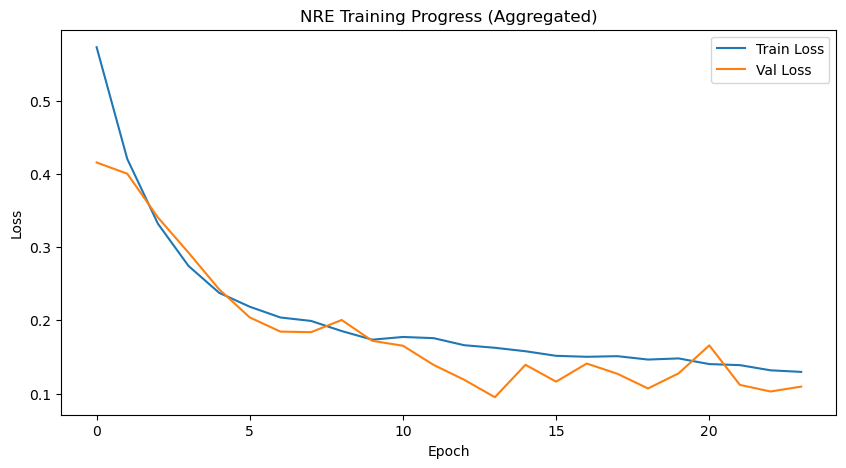

In [68]:
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")

# Aggregate by epoch to remove NaNs
# This takes the non-NaN value for each epoch
epoch_metrics = metrics.groupby('epoch').max()

plt.figure(figsize=(10, 5))


# Plot from the aggregated dataframe
if 'train_loss' in epoch_metrics.columns:
    plt.plot(epoch_metrics.index, epoch_metrics['train_loss'], label='Train Loss')


if 'val_loss' in epoch_metrics.columns:
    plt.plot(epoch_metrics.index, epoch_metrics['val_loss'], label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('NRE Training Progress (Aggregated)')
plt.show()

In [ ]:
npLoad = np.load("/home/ubuntu/SNANA/nre/gioTesting/meansNstdsSummarisedNoZ.npz")
theta_mean = npLoad["theta_mean"]
theta_std = npLoad["theta_std"]
mu_mean = npLoad["mu_mean"]
mu_std = npLoad["mu_std"]
zhd_mean = None
zhd_std = None

npLoad.close()

nre = nb.NeuralRatioEstimator.load_from_checkpoint('nreTestLogs/summariesNoZ/version_1/checkpoints/epoch=29-step=1650.ckpt', x_dim=100, theta_dim=2, hidden_dim=1020, layers=5)


nre.eval()

NeuralRatioEstimator(
  (classifier): Sequential(
    (0): Linear(in_features=102, out_features=1020, bias=True)
    (1): BatchNorm1d(1020, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=1020, out_features=1020, bias=True)
    (5): BatchNorm1d(1020, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=1020, out_features=1020, bias=True)
    (9): BatchNorm1d(1020, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=1020, out_features=1020, bias=True)
    (13): BatchNorm1d(1020, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=1020, out_features=1020, bias=True)
    (17): BatchNorm1d(1020, eps=1e-05, m

In [71]:
muReal, zReal = f.extract_mu_zhd_from_file('/home/ubuntu/SNANA/salt2mus/realdata/SALT2mu_realdata.FITRES')
zReal, muReal = f.smoother(zReal, muReal) ### smooth

ndim, nwalkers = 2, 64
sampler = emcee.EnsembleSampler(nwalkers, ndim, nb.log_post, args=(muReal, None, theta_mean, theta_std, mu_mean, mu_std, None, None, nre, False))  # Init

# pos = rng.standard_normal((nwalkers, ndim))  # should be np.random.randn equivalent # starting theta position
pos = rng.uniform((0, -3), (1, 0), size=(nwalkers, ndim))
sampler.run_mcmc(pos, 10000, progress=True)  # run

emcee: Exception while calling your likelihood function:
  params: [ 0.79100786 -0.00432333]
  args: (array([37.4380872 , 37.5033119 , 37.5685366 , 37.6337613 , 37.69898599,
       37.76421069, 37.82943539, 37.89466009, 37.95988479, 38.02510949,
       38.09033419, 38.15555889, 38.22078359, 38.28600829, 38.35123299,
       38.41645769, 38.48168238, 38.54690708, 38.61213178, 38.67735648,
       38.74258118, 38.8077076 , 38.8727379 , 38.93752772, 39.00204583,
       39.06633403, 39.13037725, 39.19428249, 39.2580583 , 39.32169867,
       39.38525855, 39.4487598 , 39.51223245, 39.57571095, 39.63923199,
       39.70280444, 39.76644591, 39.82998454, 39.89279018, 39.95089218,
       40.00871293, 40.06400499, 40.11896088, 40.17388028, 40.22918718,
       40.28337156, 40.33592771, 40.38615423, 40.43626737, 40.4854359 ,
       40.53424312, 40.58262987, 40.63056104, 40.67689295, 40.72402318,
       40.76664154, 40.80433139, 40.84152329, 40.87802159, 40.91546937,
       40.95296145, 40.98967573, 4

Traceback (most recent call last):
  File "/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/SNANA/scripts/SMC-ABC-for-Supernovae-Ia/funky/nreblocks.py", line 108, in log_post
    if z is None: lk = log_like(theta, mu, z, theta_mean, theta_std, mu_mean, mu_std, z_mean, z_std, nre)  # In case of smoother case
                       ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/SNANA/scripts/SMC-ABC-for-Supernovae-Ia/funky/nreblocks.py", line 80, in log_like
    return nre.classifier(torch.cat([xTest, thetaTest], dim=-1))
           ~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **

ValueError: expected 2D or 3D input (got 1D input)

Autocorrelation time: [34.32503374 31.60908546]


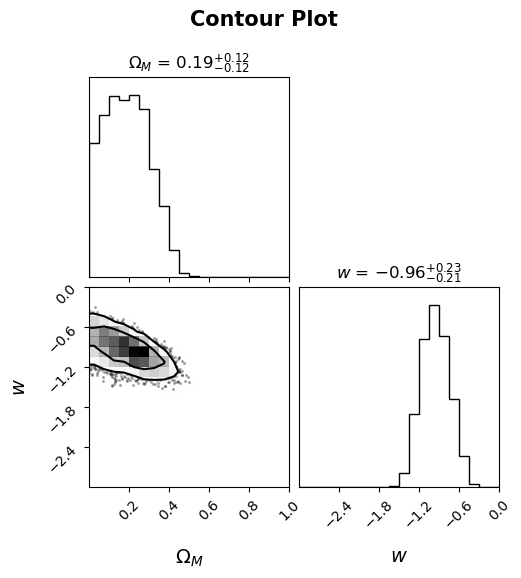

In [ ]:
print("Autocorrelation time:", sampler.get_autocorr_time(discard=5000))
flat_samples = sampler.get_chain(discard=5000, thin=75, flat=True)  # get chain, look for what's flat
fig = corner.corner(
    flat_samples, 
    range=[(0, 1), (-3, 0)], 
    labels=[r"$\Omega_M$", r"$w$"],
    #quantiles=[0.16, 0.5, 0.84],      
    show_titles=True,                 
    title_kwargs={"fontsize": 12},    
    label_kwargs={"fontsize": 14},    
    color="black",                 
    hist_kwargs={"linewidth": 1},   
    hist_bin_factor=1,
    levels=(0.68,0.95),          
    fill_contours=False,               
    plot_datapoints=True,            
    data_kwargs={"alpha": 0.4}#, "marker": "o", "markersize": 2} 
)
fig.suptitle("Contour Plot", fontsize=15, fontweight="bold", y=1.05)
plt.show()

# EHEHEHEHEHHEHE ORA PROVO AD ORDINARE GLI OSSUTI DATI
Argosorto per redshift i dati perché non siamo animali

In [9]:
with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)
N = 5500  # select number of TRAINING sims
N_val = 700
N_lc = 73  # lc per sim (maximum possible over all sims)

theta = np.empty((N, 2))
mu = np.empty((N, N_lc))
zhd = np.empty((N, N_lc))
for i in range(N):
    # omega_list[i] = train[i].get('omega')
    # w[i] = train[i].get('w')
    theta[i] = (sims[i].get('omega'), sims[i].get('w'))
    zhd[i] = sims[i].get('zhd')[:N_lc]
    idx_train = np.argsort(zhd[i])
    zhd[i] = zhd[i][idx_train]
    mu[i] = sims[i].get('mu')[:N_lc][idx_train]


# validation
theta_val = np.empty((N_val, 2))
mu_val = np.empty((N_val, N_lc))
zhd_val = np.empty((N_val, N_lc))
for i, j in enumerate(range(N, N + N_val)):
    theta_val[i] = (sims[j].get('omega'), sims[j].get('w'))
    zhd_val[i] = sims[j].get('zhd')[:N_lc]
    idx_val = np.argsort(zhd_val[i])
    zhd_val[i] = zhd_val[i][idx_val]
    mu_val[i] = sims[j].get('mu')[:N_lc][idx_val]

/tmp/ipykernel_5253/759990704.py:1: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)


In [10]:
# standardise
theta_mean, theta_std = theta.mean(axis=0), theta.std(axis=0)
mu_mean, mu_std = mu.mean(axis=0), mu.std(axis=0)
zhd_mean, zhd_std = zhd.mean(axis=0), zhd.std(axis=0)

mu = torch.tensor((mu - mu_mean) / mu_std).float()
zhd = torch.tensor((zhd - zhd_mean) / zhd_std).float()
theta = torch.tensor((theta - theta_mean) / theta_std).float()
x = torch.cat([mu,zhd], dim=1)

mu_val = torch.tensor((mu_val - mu_mean) / mu_std).float()
zhd_val = torch.tensor((zhd_val - zhd_mean) / zhd_std).float()
theta_val = torch.tensor((theta_val - theta_mean) / theta_std).float()
x_val = torch.cat([mu_val,zhd_val], dim=1)

# save means and stds, we need them to standardise the test
np.savez("/home/ubuntu/SNANA/nre/gioTesting/meansNstdsOrderedVals.npz", theta_mean=theta_mean, theta_std=theta_std, mu_mean=mu_mean, mu_std=mu_std, zhd_mean=zhd_mean, zhd_std=zhd_std)

# Evaluate loss; initially it should be around -log(0.5) = 0.693
nre = nb.NeuralRatioEstimator(x_dim=N_lc*2, theta_dim=2, hidden_dim=512, layers=10)

batch_size = 100

dataset_train, dataset_val = TensorDataset(x, theta), TensorDataset(x_val, theta_val)

train_loader = DataLoader(dataset_train, batch_size=batch_size, num_workers=3, pin_memory=True, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, num_workers=3, pin_memory=True, shuffle=False)
logger = pl.loggers.CSVLogger('test', name="Order")
trainer = pl.Trainer(max_epochs=50, logger=logger)

nre.train()
trainer.fit(model=nre, train_dataloaders=train_loader, val_dataloaders=val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name       | Type       | Params | Mode  | FLOPs
----------------------------------------------------------
0 | classifier | Sequential | 2.7 M  | train | 0    
----------------------------------------------------------
2.7 M     Trainable params
0         Non-trainable params
2.7 M     Total params
10.813    Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |                                                               | 0/? [00:00<?, ?it/s]

/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |                                                                      | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

...

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


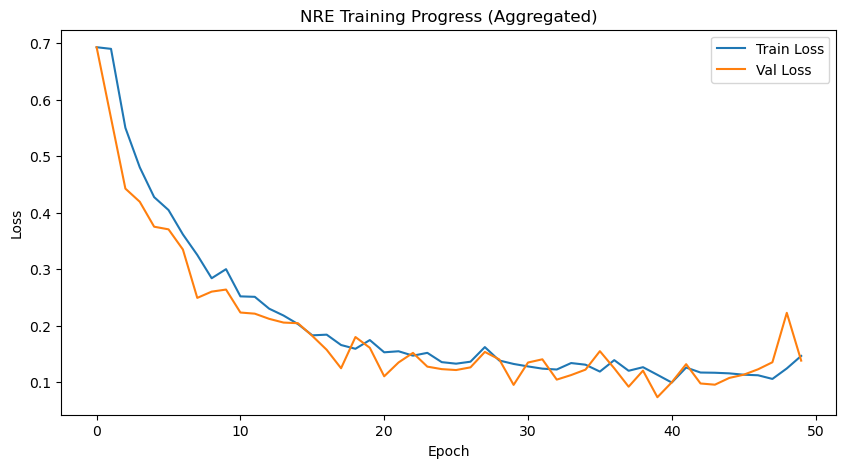

In [11]:
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")

# Aggregate by epoch to remove NaNs
# This takes the non-NaN value for each epoch
epoch_metrics = metrics.groupby('epoch').max()

plt.figure(figsize=(10, 5))


# Plot from the aggregated dataframe
if 'train_loss' in epoch_metrics.columns:
    plt.plot(epoch_metrics.index, epoch_metrics['train_loss'], label='Train Loss')

if 'val_loss' in epoch_metrics.columns:
    plt.plot(epoch_metrics.index, epoch_metrics['val_loss'], label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('NRE Training Progress (Aggregated)')
plt.show()

In [ ]:
npLoad = np.load("/home/ubuntu/SNANA/nre/gioTesting/meansNstdsOrderedVals.npz")
theta_mean = npLoad["theta_mean"]
theta_std = npLoad["theta_std"]
mu_mean = npLoad["mu_mean"]
mu_std = npLoad["mu_std"]
zhd_mean = npLoad["zhd_mean"]
zhd_std = npLoad["zhd_std"]

npLoad.close()

nre = nb.NeuralRatioEstimator.load_from_checkpoint('nreTestLogs/Order/version_2/checkpoints/epoch=49-step=2750.ckpt', x_dim=73*2, theta_dim=2, hidden_dim=512, layers=10)
nre.eval()

In [ ]:
muReal, zReal = f.extract_mu_zhd_from_file('/home/ubuntu/SNANA/salt2mus/realdata/SALT2mu_realdata.FITRES')
# idxReal = np.argsort(zReal)
# zReal = zReal[idxReal]
# muReal = muReal[idxReal]

ndim, nwalkers = 2, 32
samplerOrder = emcee.EnsembleSampler(nwalkers, ndim, nb.log_post, args=(muReal, zReal, theta_mean, theta_std, mu_mean, mu_std, zhd_mean, zhd_std, nre, True))  # Init

# pos = rng.standard_normal((nwalkers, ndim))  # should be np.random.randn equivalent # starting theta position
pos = rng.uniform((0, -3), (1, 0), size=(nwalkers, ndim))
# pos = rng.uniform((-3, 0), (0, 1), size=(nwalkers, ndim))
samplerOrder.run_mcmc(pos, 5000, progress=True)  # run

In [17]:
samplerOrder.get_autocorr_time(discard=1000, quiet=True)

/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]
The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 80;
tau: [         nan 555.29299753]


array([         nan, 555.29299753])

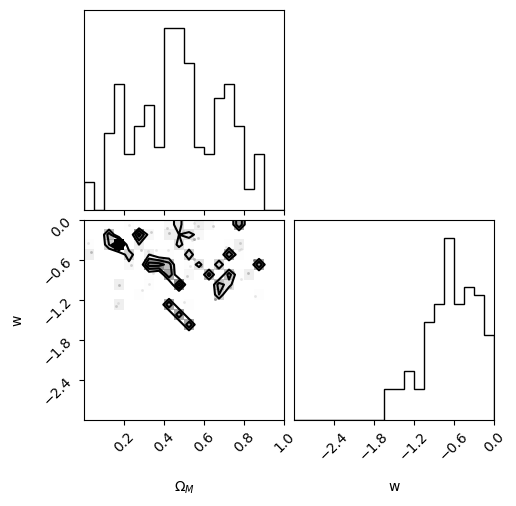

In [ ]:
flat_samples = samplerOrder.get_chain(discard=1000, thin=560, flat=True)  # get chain, look for what's flat
fig = corner.corner(
    flat_samples, 
    range=[(0, 1), (-3, 0)], 
    labels=[r"$\Omega_M$", r"$w$"],
    #quantiles=[0.16, 0.5, 0.84],      
    show_titles=True,                 
    title_kwargs={"fontsize": 12},    
    label_kwargs={"fontsize": 14},    
    color="black",                 
    hist_kwargs={"linewidth": 1},   
    hist_bin_factor=1,
    levels=(0.68,0.95),          
    fill_contours=False,               
    plot_datapoints=True,            
    data_kwargs={"alpha": 0.4}#, "marker": "o", "markersize": 2} 
)
fig.suptitle("Contour Plot", fontsize=15, fontweight="bold", y=1.05)
plt.show()

# Useless testing

In [33]:
defeatParam = [.4, -3]
despairParam = [.4, -2.3]
mu4, z4 = f.sim_wrapper(defeatParam, 'defeat')
mu2, z2 = f.sim_wrapper(despairParam, 'despair')
# z_sim,mu_sim=(f.smoother(zhd,mu))

Removed /home/ubuntu/SNANA/SNROOT/SIM/defeat/defeat_SN000092.DAT bc no obs that t1 - t0 < 0.
Removed /home/ubuntu/SNANA/SNROOT/SIM/defeat/defeat_SN000083.DAT bc no obs that t1 - t0 < 0.
Removed /home/ubuntu/SNANA/SNROOT/SIM/defeat/defeat_SN000064.DAT bc no obs that t1 - t0 < 0.
Removed /home/ubuntu/SNANA/SNROOT/SIM/despair/despair_SN000066.DAT bc no obs that t1 - t0 < 0.
Removed /home/ubuntu/SNANA/SNROOT/SIM/despair/despair_SN000085.DAT bc no obs that t1 - t0 < 0.
Removed /home/ubuntu/SNANA/SNROOT/SIM/despair/despair_SN000096.DAT bc no obs that t1 - t0 < 0.


In [34]:
# smZreal, smMreal = f.smoother(zReal, muReal)
sz4, smu4 = f.smoother(z4, mu4)
sz2, smu2 = f.smoother(z2, mu2)

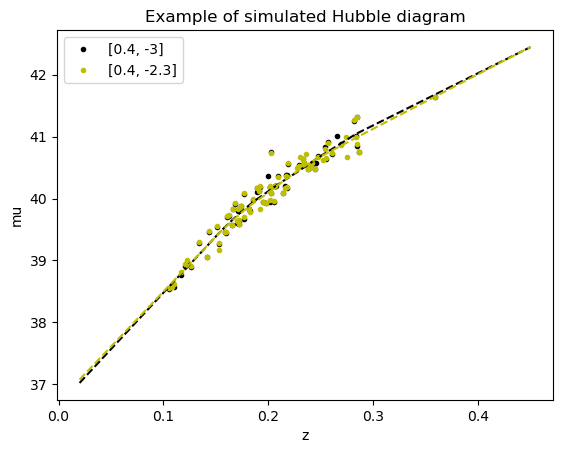

In [35]:
# plt.plot(zReal, muReal, '.r', label='real')
plt.plot(z4,mu4, '.k', label=str(defeatParam))
plt.plot(z2, mu2, '.y', label=str(despairParam))
# plt.plot(smZreal, smMreal, 'r', ls='--')
plt.plot(sz4, smu4, 'k', ls='--')
plt.plot(sz2, smu2, 'y', ls='--')
plt.title('Example of simulated Hubble diagram')
plt.legend()
plt.xlabel('z')
plt.ylabel('mu')
plt.show()

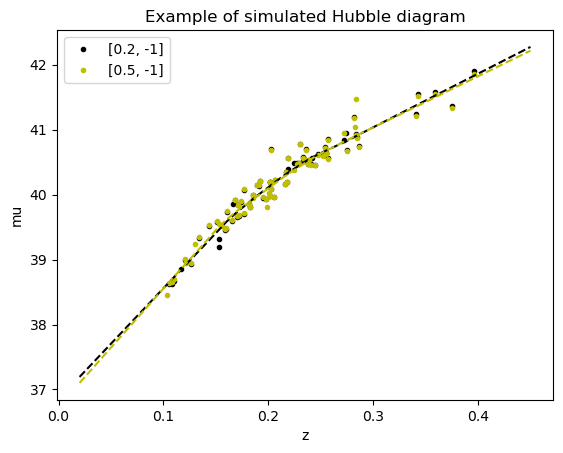

In [32]:
# plt.plot(zReal, muReal, '.r', label='real')
plt.plot(z4,mu4, '.k', label=str(defeatParam))
plt.plot(z2, mu2, '.y', label=str(despairParam))
# plt.plot(smZreal, smMreal, 'r', ls='--')
plt.plot(sz4, smu4, 'k', ls='--')
plt.plot(sz2, smu2, 'y', ls='--')
plt.title('Example of simulated Hubble diagram')
plt.legend()
plt.xlabel('z')
plt.ylabel('mu')
plt.show()

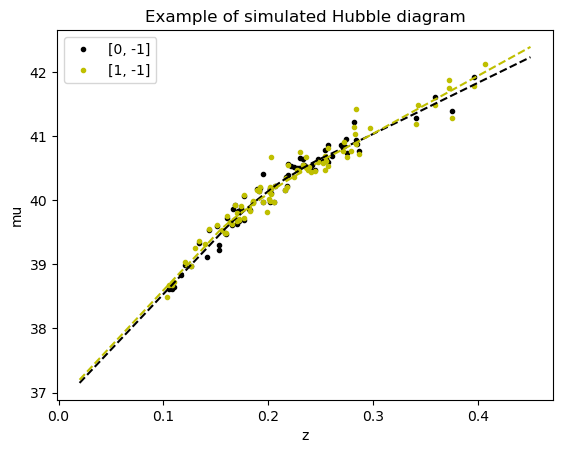

In [29]:
# plt.plot(zReal, muReal, '.r', label='real')
plt.plot(z4,mu4, '.k', label=str(defeatParam))
plt.plot(z2, mu2, '.y', label=str(despairParam))
# plt.plot(smZreal, smMreal, 'r', ls='--')
plt.plot(sz4, smu4, 'k', ls='--')
plt.plot(sz2, smu2, 'y', ls='--')
plt.title('Example of simulated Hubble diagram')
plt.legend()
plt.xlabel('z')
plt.ylabel('mu')
plt.show()